# Tariikhna — Fine-Tuning Llama 3.1 8B (Google Colab)

Fine-tunes Llama 3.1 8B on your Tariikhna training data (scene -> schema) using
**Unsloth + QLoRA** on a free Colab T4 GPU.

### Before running:
1. Runtime -> Change runtime type -> **T4 GPU**
2. Upload your `tariikhna_training.jsonl` (from the data pipeline)
3. Run all cells

Training takes ~30-60 minutes on a free T4.

## 1. Install Unsloth

In [ ]:
# Unsloth install for Colab
!pip install unsloth -q
# Get latest nightly for newest features/fixes
!pip install --force-reinstall --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git -q
print('Unsloth installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6

In [ ]:
# Verify GPU
import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU: Tesla T4
VRAM: 15.6 GB


## 2. Load the Model

We load a pre-quantized 4-bit version of Llama 3.1 8B Instruct.

**Why 4-bit?** The full 16-bit model is ~16GB and won't fit on a T4's 16GB VRAM alongside
training overhead. The 4-bit version is ~5.4GB, leaving room for training.

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 4096   # our prompts + schema outputs are long (detailed image prompts)
dtype = None            # auto-detect (bf16 on newer GPUs, fp16 on T4)
load_in_4bit = True     # QLoRA - 4-bit quantization

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit',
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)
print('Model loaded!')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.


Model loaded!


## 3. Add LoRA Adapters

Instead of training all 8 billion parameters (impossible on a T4), we add small
trainable 'adapter' matrices to key layers. Only these adapters train - the base
model stays frozen. This is the core of LoRA/QLoRA efficiency.

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,                    # LoRA rank - capacity of the adapters
    target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                      'gate_proj', 'up_proj', 'down_proj'],  # all attention + MLP layers
    lora_alpha = 16,           # scaling factor (commonly = rank)
    lora_dropout = 0,          # 0 is optimized in Unsloth
    bias = 'none',             # don't train bias terms (optimized)
    use_gradient_checkpointing = 'unsloth',  # saves VRAM for long sequences
    random_state = 3407,       # reproducibility
    use_rslora = False,
    loftq_config = None,
)
print('LoRA adapters added!')

# Show how few parameters we actually train
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} ({100*trainable/total:.2f}% of {total:,})')

Unsloth 2026.6.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


LoRA adapters added!
Trainable params: 41,943,040 (0.92% of 4,582,543,360)


## 4. Load & Format Your Data

Upload `tariikhna_training.jsonl`, then we apply Llama 3.1's chat template.

In [ ]:
# Upload the training file (Colab file picker)
from google.colab import files
print('Upload your tariikhna_training.jsonl:')
uploaded = files.upload()
TRAIN_FILE = list(uploaded.keys())[0]
print(f'Uploaded: {TRAIN_FILE}')

Upload your tariikhna_training.jsonl:


Saving tariikhna_training.jsonl to tariikhna_training (1).jsonl
Uploaded: tariikhna_training (1).jsonl


In [ ]:
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template

# Apply Llama 3.1 chat template to the tokenizer
tokenizer = get_chat_template(tokenizer, chat_template='llama-3.1')

# Load the JSONL (each line has a 'messages' list)
dataset = load_dataset('json', data_files=TRAIN_FILE, split='train')
print(f'Loaded {len(dataset)} training examples')

# Format each example's messages with the chat template
def format_chat(examples):
    texts = []
    for messages in examples['messages']:
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        texts.append(text)
    return {'text': texts}

dataset = dataset.map(format_chat, batched=True)

# Preview one formatted example
print('\n--- Sample formatted example (first 800 chars) ---')
print(dataset[0]['text'][:800])

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 241 training examples


Map:   0%|          | 0/241 [00:00<?, ? examples/s]


--- Sample formatted example (first 800 chars) ---
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

You are a specialist in creating children's Islamic educational comics (ages 6-12) for the Tariikhna platform.

Convert ONE visual scene into a complete schema with a DETAILED image generation prompt.

=== ISLAMIC DEPICTION RULES (CRITICAL) ===
- Prophets: NEVER show face. Show ONLY from behind, distinguished by clothing (e.g. green cloak). In the image_prompt, refer to a prophet as 'the central figure seen from behind' or 'the man in the green cloak' - NEVER use the literal word 'prophet' in image_prompt.
- Women: always fully and modestly dressed (jilbab, khimar covering hair). Describe clothing, not body.
- Others (companions, antagonists, crowds): shown normally 


## 5. Configure Training

Each parameter is explained - useful for your graduation document.

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = 'text',
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,           # don't pack multiple examples per sequence (keeps examples clean)
    args = TrainingArguments(
        per_device_train_batch_size = 2,    # how many examples per step (T4 memory limited)
        gradient_accumulation_steps = 4,    # effective batch size = 2*4 = 8
        warmup_steps = 5,                   # gentle LR ramp-up
        num_train_epochs = 3,               # passes over the dataset (3 is good for small data)
        # max_steps = 60,                   # alternative: cap by steps instead of epochs
        learning_rate = 2e-4,               # standard for LoRA
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,                  # log loss every step (for the loss curve)
        optim = 'adamw_8bit',               # memory-efficient optimizer
        weight_decay = 0.01,                # regularization
        lr_scheduler_type = 'linear',       # LR decays linearly
        seed = 3407,
        output_dir = 'outputs',
        report_to = 'none',
        save_strategy = 'no'
    ),
)
print('Trainer configured!')

Unsloth: Tokenizing ["text"] (num_proc=6):  33%|###3      | 80/241 [00:00<?, ? examples/s]

Trainer configured!


## 6. Train!

We capture the training stats so we can plot the loss curve afterward (for your document).

In [ ]:
# Show memory before
gpu_stats = torch.cuda.get_device_properties(0)
start_mem = round(torch.cuda.max_memory_reserved() / 1e9, 2)
print(f'GPU: {gpu_stats.name}, Reserved before: {start_mem} GB')

# TRAIN
trainer_stats = trainer.train()

GPU: Tesla T4, Reserved before: 15.42 GB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 241 | Num Epochs = 3 | Total steps = 93
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Step,Training Loss
1,0.100428
2,0.098970
3,0.092341
4,0.084780
5,0.096673
6,0.107998
7,0.109864
8,0.092440
9,0.096582
10,0.099181


In [ ]:
# Training summary (useful numbers for your document)
used_mem = round(torch.cuda.max_memory_reserved() / 1e9, 2)
print(f'Training time: {trainer_stats.metrics["train_runtime"]:.0f}s ({trainer_stats.metrics["train_runtime"]/60:.1f} min)')
print(f'Peak VRAM: {used_mem} GB')
print(f'Final training loss: {trainer_stats.metrics["train_loss"]:.4f}')

Training time: 1456s (24.3 min)
Peak VRAM: 15.42 GB
Final training loss: 0.0706


## 7. Plot the Loss Curve (for your document)

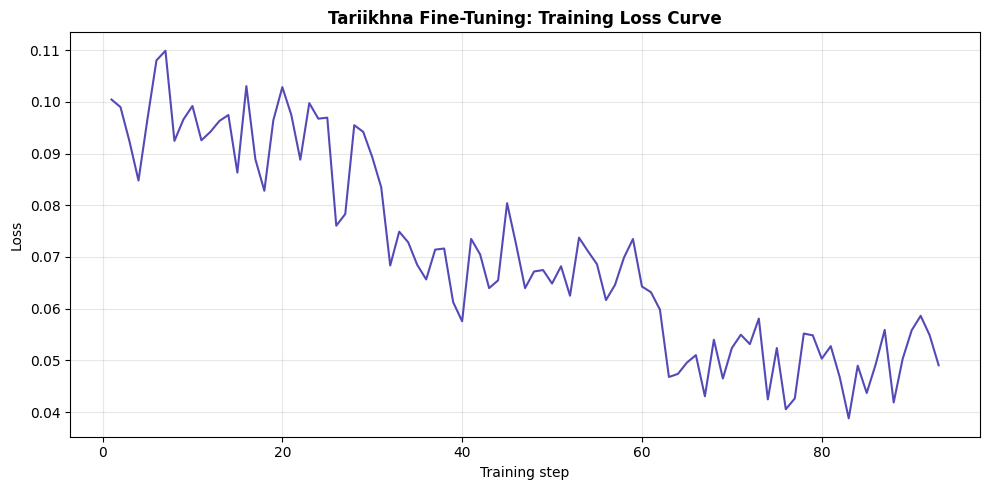

Saved training_loss_curve.png - use this in your document!


In [ ]:
import matplotlib.pyplot as plt

# Extract loss history
history = trainer.state.log_history
steps = [h['step'] for h in history if 'loss' in h]
losses = [h['loss'] for h in history if 'loss' in h]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, color='#534AB7', linewidth=1.5)
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Tariikhna Fine-Tuning: Training Loss Curve', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_loss_curve.png - use this in your document!')

## 8. Test the Fine-Tuned Model

In [ ]:
# Switch to inference mode (2x faster)
FastLanguageModel.for_inference(model)

# Test with a sample scene (the kind Layer 1c produces)
test_scene = {
    'scene_summary': 'Bilal is freed by Abu Bakr after being tortured for his faith',
    'key_visual_action': 'Abu Bakr placing a protective hand on Bilal\'s shoulder as he stands freed',
    'characters_present': ['Abu Bakr', 'Bilal'],
    'setting': 'A Makkah street in harsh midday sun',
    'emotional_tone': 'relief and gratitude',
    'time_of_day': 'midday'
}

messages = [
    {'role': 'system', 'content': 'You are a specialist in creating children\'s Islamic educational comics for Tariikhna. Convert the scene into a complete schema with a detailed 250-300 word image prompt. Follow Islamic depiction rules: prophets never shown by face, women modestly dressed. Output only JSON.'},
    {'role': 'user', 'content': f'Generate the schema for this scene:\n\n{test_scene}'}
]

inputs = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors='pt'
).to('cuda')

outputs = model.generate(input_ids=inputs, max_new_tokens=1024, temperature=0.6, use_cache=True)
response = tokenizer.batch_decode(outputs)[0]
# Print just the generated part
print(response.split('assistant')[-1][:2000])

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|end_header_id|>

{"scene_number": 1, "scene_summary": "Bilal is freed by Abu Bakr after being tortured for his faith", "key_visual_action": "Abu Bakr placing a protective hand on Bilal's shoulder as he stands freed", "characters_present": [{"name": "Abu Bakr", "role": "Companion", "depiction_rule": "show full face", "clothing": "simple white thobe and brown woolen cloak", "gesture": "protective hand on Bilal's shoulder"}, {"name": "Bilal", "role": "Companion", "depiction_rule": "show full face", "clothing": "simple white thobe and brown woolen cloak", "emotional_state": "relieved and grateful"}], "setting": {"location": "A Makkah street", "environment": "harsh midday sun", "architecture": "traditional Makkah buildings in the background", "furniture": "piles of rocks or palm fronds as makeshift seats", "objects": "scattered trash and debris"}, "emotional_tone": "relief and gratitude", "time_of_day": "midday", "color_palette": {"primary": "warm golden light", "secondary": "cool blues a

## 9. Save the Model

Save the LoRA adapters (small, ~100MB) and optionally merge to full model.

In [ ]:
# Save LoRA adapters only (small, fast)
model.save_pretrained('tariikhna_lora')
tokenizer.save_pretrained('tariikhna_lora')
print('LoRA adapters saved to tariikhna_lora/')

# Zip and download
import shutil
shutil.make_archive('tariikhna_lora', 'zip', 'tariikhna_lora')
from google.colab import files
files.download('tariikhna_lora.zip')
files.download('training_loss_curve.png')

Unsloth: Restored added_tokens_decoder metadata in tariikhna_lora/tokenizer_config.json.


LoRA adapters saved to tariikhna_lora/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# OPTIONAL: Save merged 16-bit model (full, ~16GB - only if you need standalone)
# model.save_pretrained_merged('tariikhna_merged', tokenizer, save_method='merged_16bit')

# OPTIONAL: Push to Hugging Face Hub
# model.push_to_hub('your-username/tariikhna-llama', token='hf_...')

# OPTIONAL: Export to GGUF for Ollama/llama.cpp
# model.save_pretrained_gguf('tariikhna_gguf', tokenizer, quantization_method='q4_k_m')

print('See commented options above for other export formats')

## 10. How to Use the Saved Adapters Later

```python
from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = 'tariikhna_lora',  # your saved adapters
    max_seq_length = 4096,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)
# ... then generate as in cell 8
```

In [1]:
# ============================================================
# CELL A — run once, installs the tiny server's dependencies
# ============================================================
!pip install fastapi uvicorn pyngrok nest-asyncio -q
print("Server dependencies installed.")

Server dependencies installed.


In [6]:
# ============================================================
# CELL B — defines the inference server
#
# IMPORTANT: this assumes `model` and `tokenizer` are already loaded
# in this notebook's memory (from your fine-tuning cells, or reloaded
# via FastLanguageModel.from_pretrained if you restarted the runtime).
# If you restarted the runtime, run the "reload" cell at the bottom
# of your notebook (Section 10) FIRST, before this cell.
# ============================================================
import nest_asyncio
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn

nest_asyncio.apply()  # lets uvicorn run inside Colab's existing event loop

app = FastAPI()

# Make sure the model is in inference mode (2x faster, no gradient tracking)
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)


class GenerateRequest(BaseModel):
    system_prompt: str
    user_prompt: str


class GenerateResponse(BaseModel):
    text: str


@app.post("/generate", response_model=GenerateResponse)
def generate(req: GenerateRequest):
    messages = [
        {"role": "system", "content": req.system_prompt},
        {"role": "user", "content": req.user_prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        input_ids=inputs, max_new_tokens=1024, temperature=0.6, use_cache=True
    )
    full_text = tokenizer.batch_decode(outputs)[0]
    generated_part = full_text.split("assistant")[-1]
    return GenerateResponse(text=generated_part)


@app.get("/")
def health():
    return {"status": "ok", "service": "tariikhna-llm-server"}


print("FastAPI app defined. Run the next cell to expose it via ngrok.")

FastAPI app defined. Run the next cell to expose it via ngrok.


In [ ]:
# ============================================================
# CELL C (FIXED) — exposes the server publicly via ngrok and starts it.
#
# This cell BLOCKS while the server runs (expected). Leave it running
# while you generate scenes. Stop it (interrupt/stop button) when done.
# ============================================================
from pyngrok import ngrok
import nest_asyncio
import asyncio

nest_asyncio.apply()

# Paste your ngrok authtoken here (from https://dashboard.ngrok.com/get-started/your-authtoken)
NGROK_AUTH_TOKEN = "3FbHX4WqPoMU0xDR1mXFZliksBE_5qN4Tog5tEPQAGK8LsMUc"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Kill any previously open tunnels from earlier failed attempts, to avoid
# hitting ngrok's free-tier limit of 1 simultaneous tunnel
ngrok.kill()

# Open the tunnel to port 8000, where uvicorn will run the FastAPI app
tunnel = ngrok.connect(8000)
public_url = tunnel.public_url  # <-- this is the clean string, e.g. "https://abc123.ngrok-free.dev"

print("=" * 60)
print(f"Public URL: {public_url}")
print(f"Use this in your .env as:")
print(f"LLM_REMOTE_URL={public_url}/generate")
print("=" * 60)

# Run the server using the Server class directly (works inside Colab's
# already-running event loop, unlike the blocking uvicorn.run()).
config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
server = uvicorn.Server(config)
await server.serve()

Public URL: https://bacteria-doable-superhero.ngrok-free.dev
Use this in your .env as:
LLM_REMOTE_URL=https://bacteria-doable-superhero.ngrok-free.dev/generate


INFO:     Started server process [10278]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.w

INFO:     197.42.213.112:0 - "POST /generate HTTP/1.1" 200 OK


Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


INFO:     197.42.213.112:0 - "POST /generate HTTP/1.1" 200 OK


...

INFO:     197.42.213.112:0 - "POST /generate HTTP/1.1" 200 OK


Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INFO:     197.42.213.112:0 - "POST /generate HTTP/1.1" 200 OK


Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INFO:     197.42.213.112:0 - "POST /generate HTTP/1.1" 200 OK


In [3]:
# Run this first to check what state the runtime is actually in
try:
    import unsloth
    print("unsloth is installed.")
except ImportError:
    print("unsloth is NOT installed — this is a fresh/restarted runtime.")

try:
    model
    print("`model` variable exists in memory.")
except NameError:
    print("`model` variable does NOT exist — needs to be reloaded.")

try:
    tokenizer
    print("`tokenizer` variable exists in memory.")
except NameError:
    print("`tokenizer` variable does NOT exist — needs to be reloaded.")

unsloth is NOT installed — this is a fresh/restarted runtime.
`model` variable does NOT exist — needs to be reloaded.
`tokenizer` variable does NOT exist — needs to be reloaded.


In [4]:
# ============================================================
# Run this in a FRESH Colab runtime to get back to a working state
# WITHOUT redoing fine-tuning. This loads your already-merged model
# straight from Hugging Face Hub.
#
# Make sure Runtime -> Change runtime type -> T4 GPU is selected first.
# ============================================================

# 1. Install unsloth (needed every time the runtime restarts)
!pip install unsloth -q
!pip install --force-reinstall --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git -q

print("unsloth installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 904.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

In [5]:
# ============================================================
# Run this AFTER the unsloth install cell above.
# Loads your already fine-tuned, merged model directly from HF Hub —
# no training happens here, this is pure inference loading.
# ============================================================
from huggingface_hub import login
from unsloth import FastLanguageModel
import torch

# If your HF repo is PRIVATE (recommended), you need to log in first.
# Paste a token with at least "read" access when prompted.
login()

HF_REPO = "MohamedShata/tariikhna-llama-3.1-8b-lora"  # <-- same repo you pushed to earlier

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=HF_REPO,
    max_seq_length=4096,
    load_in_4bit=True,
)

print("Model and tokenizer loaded from Hugging Face Hub.")
print("You can now run Cell B (server definition) and Cell C (ngrok) as before.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.


adapter_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Model and tokenizer loaded from Hugging Face Hub.
You can now run Cell B (server definition) and Cell C (ngrok) as before.
